### Imports

In [1]:
import math
import matplotlib.pyplot as plt
import numpy as np
import random

%matplotlib inline

### Generate Data

In [159]:
# Add some random delta to the values
def random_delta():
    return (random.random() - 0.5) * 20.0

xs = [x for x in range(0, 160)]
ys = [(7*x + 5.0) + random_delta() for x in xs]

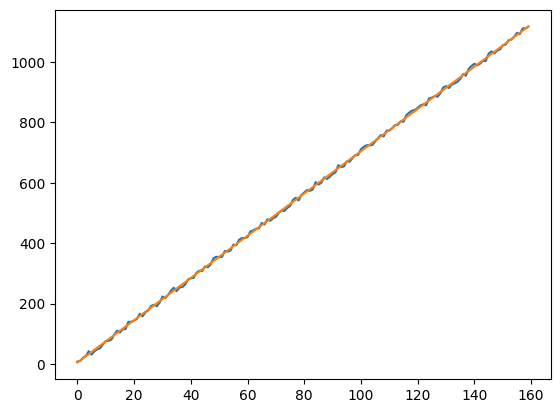

In [160]:
# Plot the data
plt.plot(xs, ys)

# This should be close to the line of best fit
ys_best = [(7*x + 5.0) for x in xs]

# Plot the line of best fit
plt.plot(xs, ys_best)
plt.show()

### Forward and backward passes

In [202]:
def forward_prop(w, b, x):
    y_pred = [(w*x[i] + b) for i in range(len(x))]
    return y_pred

def back_prop(x, y_pred, y):
    N = len(y)
    
    # dL/dw = (2 / N) * sum((y_pred - y_i) * x_i)
    sum1 = sum([(y_pred[i] - y[i]) * x[i] for i in range(N)])
    dw = (2.0 / N) * sum1
        
    # dL/db = (2 / N) * sum(y_pred_i - y_i)
    sum2 = sum([(y_pred[i] - y[i]) for i in range(N)])
    db = (2.0 / N) * sum2
    return dw, db

In [203]:
def get_loss(y_pred, y):
    loss = 0.0
    N = len(y)
    
    for i in range(N):
        diff = y_pred[i] - y[i]
        loss = loss + diff**2
    
    return loss / N

### Train model

In [214]:
EPOCHS = 2500
lr = 0.0001
N = len(xs)
BATCH_SIZE = 8

w = random.random()
b = 0.0

367562.80334286


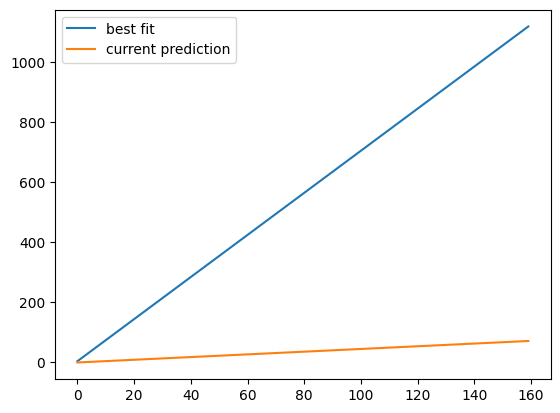

In [220]:
y_pred = forward_prop(w, b, xs)

loss = get_loss(y_pred, ys)
print(loss)

plt.plot(xs, ys_best, label='best fit')
plt.plot(xs, y_pred, label='current prediction')
plt.legend()

plt.show()

In [221]:
for _ in range(EPOCHS):
    for i in range(0, N, BATCH_SIZE):
        xs_batch = xs[i:i+BATCH_SIZE]
        ys_batch = ys[i:i+BATCH_SIZE]
        
        y_pred = forward_prop(w, b, xs_batch)

        # update the weights and biases using gradient descent
        dw, db = back_prop(xs, y_pred, ys_batch)
        w = w - lr*dw
        b = b - lr*db

    # Print the loss
    y_pred = forward_prop(w, b, xs)
    # loss = get_loss(y_pred, ys)    
    
    #print("w: {}, b: {}".format(w, b))
    #print("dw: {}, db: {}".format(dw, db))
    #print("loss: {}".format(loss))

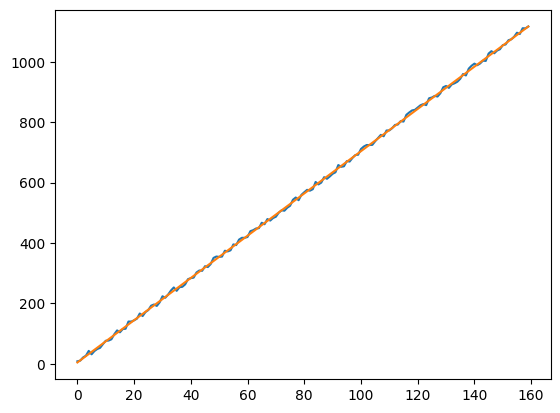

loss: 33.71961218240114
w: 7.002550314958284, b: 4.062361794438093


In [222]:
plt.plot(xs, ys)

ys_best = [(w*x + b) for x in xs]
plt.plot(xs, ys_best)
plt.show()

y_pred = forward_prop(w, b, xs)
print("loss: {}".format(get_loss(y_pred, ys)))
print("w: {}, b: {}".format(w, b))